# Tier 2 · Notebook 11 — GPT From Scratch (the flagship)

> **Goal:** assemble everything — token + positional embeddings, **causal multi-head attention** (NB10), a feed-forward MLP, **LayerNorm** (NB3) and **residual connections** (NB5) — into a complete **decoder-only transformer**, and train it to generate text. This is the architecture behind GPT-2/3/4, built from parts you now fully understand.

**What a GPT actually is, in one sentence:** a stack of identical transformer blocks that, given a sequence of tokens, predicts the probability distribution of the *next* token — trained by making that prediction match the real next token across a huge corpus, then used to *generate* by sampling one token at a time and feeding it back.

We build it in PyTorch (for GPU speed and autograd), but **we write every component ourselves** — no `nn.Transformer`, no `nn.MultiheadAttention`. Every matmul is one you've seen. We'll verify our hand-written attention against PyTorch's optimized kernel, train on character-level text, generate samples, and *look inside* at the learned attention.


## 0. The anatomy of one transformer block

Each block does two things, each wrapped in a **residual connection** with **pre-LayerNorm**:
$$x \leftarrow x + \text{CausalAttention}(\text{LN}(x)) \qquad\text{(mix information across positions)}$$
$$x \leftarrow x + \text{MLP}(\text{LN}(x)) \qquad\text{(process each position independently)}$$
- **Attention** is the *only* place tokens talk to each other; the causal mask keeps it autoregressive.
- The **MLP** (a 2-layer feed-forward, usually 4× wider in the middle, GELU activation) is applied to each position separately — it's where most parameters and "thinking" per token live.
- **Residuals** give gradients a highway through the deep stack (NB5); **pre-LN** keeps activations well-scaled (NB3/NB5). Modern GPTs put LayerNorm *before* each sub-layer (pre-norm) for training stability.

Let's build it.


In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(1337); np.random.seed(1337)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads, self.dk = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3*d_model)          # combined Q,K,V projection
        self.proj = nn.Linear(d_model, d_model)           # output projection W_O
        self.drop = nn.Dropout(dropout)
        # lower-triangular causal mask, registered as a buffer (not a parameter)
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)).bool())
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)             # each (B, T, C)
        # (B, T, C) -> (B, n_heads, T, dk)
        q = q.view(B, T, self.n_heads, self.dk).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.dk).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.dk).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / (self.dk ** 0.5)         # scaled scores (B,h,T,T)
        att = att.masked_fill(~self.mask[:T, :T], float("-inf"))    # causal mask
        att = F.softmax(att, dim=-1)
        self.last_att = att.detach()                                # stash for visualization
        out = att @ v                                               # (B,h,T,dk)
        out = out.transpose(1, 2).contiguous().view(B, T, C)        # re-assemble heads
        return self.drop(self.proj(out))

class Block(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model); self.attn = CausalSelfAttention(d_model, n_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, 4*d_model), nn.GELU(),
                                 nn.Linear(4*d_model, d_model), nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.ln1(x))        # residual around attention (pre-LN)
        x = x + self.mlp(self.ln2(x))         # residual around MLP (pre-LN)
        return x

print("transformer block defined (causal attention + MLP + residual + pre-LN)")


device: cuda
transformer block defined (causal attention + MLP + residual + pre-LN)


## 1. The full GPT

Wrap the block stack with the three things that turn it into a language model:
1. a **token embedding** (`vocab → d_model`) that maps each token id to a vector,
2. a **positional embedding** (learned here, one vector per position) added on — because attention is order-blind (NB10),
3. a final LayerNorm and a **language-model head** (`d_model → vocab`) producing next-token logits.

We tie nothing fancy; this is essentially nanoGPT. Note the **weight-tying-free**, minimal version for clarity.


In [2]:
class GPT(nn.Module):
    def __init__(self, vocab, d_model=128, n_heads=4, n_layers=4, block_size=64, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab, d_model)          # token -> vector
        self.pos_emb = nn.Embedding(block_size, d_model)     # position -> vector (learned)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, block_size, dropout) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab, bias=False)    # -> next-token logits
    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))  # (B,T,C): token + position
        for blk in self.blocks: x = blk(x)
        logits = self.head(self.ln_f(x))                      # (B,T,vocab)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss
    @torch.no_grad()
    def generate(self, idx, max_new, temperature=1.0, top_k=None):
        for _ in range(max_new):
            idx_cond = idx[:, -self.block_size:]              # crop to context window
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature           # last position's next-token logits
            if top_k:
                v, _ = torch.topk(logits, top_k); logits[logits < v[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            nxt = torch.multinomial(probs, 1)                 # sample
            idx = torch.cat([idx, nxt], dim=1)                # append and continue
        return idx

# set up a small model to verify our attention against PyTorch's fused kernel
_gpt = GPT(vocab=65, block_size=16).to(device).eval()    # eval() disables dropout for a clean compare
_x = torch.randn(2, 16, 128, device=device)
_blk = _gpt.blocks[0].attn
print("setup ready — verifying attention next")


setup ready — verifying attention next


In [3]:
# verification: compare our hand-written causal multi-head attention to torch's fused kernel
with torch.no_grad():
    B,T,C = _x.shape
    q,k,v = _blk.qkv(_x).split(C, 2)
    sp = lambda t: t.view(B,T,_blk.n_heads,_blk.dk).transpose(1,2)
    ref = _blk.proj(F.scaled_dot_product_attention(sp(q),sp(k),sp(v),is_causal=True)
                    .transpose(1,2).contiguous().view(B,T,C))
    ours = _blk(_x)
err = (ours - ref).abs().max().item()
print(f"our causal multi-head attention vs F.scaled_dot_product_attention: max abs err = {err:.2e}")
assert err < 1e-5
print("✅ our from-scratch GPT attention matches PyTorch's optimized kernel")


our causal multi-head attention vs F.scaled_dot_product_attention: max abs err = 1.64e-07
✅ our from-scratch GPT attention matches PyTorch's optimized kernel


## 2. Data — character-level text

We train on character-level text (predict the next character). We try to fetch the tiny-Shakespeare corpus (~1MB, the canonical nanoGPT dataset); if offline, we fall back to a bundled repeating corpus so the notebook always runs. Tokenization here is trivial — each unique character is a token (we build a real BPE tokenizer in NB12).


In [4]:
import urllib.request, pathlib

def load_tinyshakespeare(limit=None, cache="../data/tinyshakespeare.txt"):
    """Fetch once, cache to disk, and fail loudly if it cannot.

    The old version fell back to a short string repeated a few thousand times, which trains
    fine and prints confident numbers -- from a corpus with almost no entropy. An outage has
    to look like an outage, not like a result.
    """
    p = pathlib.Path(cache)
    if not p.exists():
        p.parent.mkdir(parents=True, exist_ok=True)
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        try:
            p.write_text(urllib.request.urlopen(url, timeout=15).read().decode("utf-8"), encoding="utf-8")
        except Exception as e:
            raise RuntimeError(
                f"tiny-shakespeare download failed ({e!r}). Every number in this notebook depends on "
                f"this corpus, so it stops here rather than training on placeholder text. "
                f"Download it manually to {p.resolve()} and re-run."
            ) from e
    text = p.read_text(encoding="utf-8")
    return text[:limit] if limit else text

text = load_tinyshakespeare()
print("loaded tiny-shakespeare:", len(text), "chars")

chars = sorted(set(text)); vocab = len(chars)
stoi = {c:i for i,c in enumerate(chars)}; itos = {i:c for i,c in enumerate(chars)}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9*len(data)); train_data, val_data = data[:n], data[n:]
print(f"vocab {vocab}, train {len(train_data)}, val {len(val_data)}")


loaded tiny-shakespeare: 1115394 chars
vocab 65, train 1003854, val 111540


## 3. Train the GPT

A small config (4 layers, 4 heads, $d_\text{model}=128$, context 64) — enough to learn Shakespearean character statistics in a couple of minutes on a GPU. Standard recipe: AdamW, and we track train/val loss.


In [5]:
block_size = 64; batch_size = 64
def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

model = GPT(vocab, d_model=128, n_heads=4, n_layers=4, block_size=block_size, dropout=0.1).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"GPT parameters: {n_params:,}")
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.1)

@torch.no_grad()
def est_loss():
    model.eval(); out = {}
    for split in ["train", "val"]:
        losses = torch.stack([model(*get_batch(split))[1] for _ in range(20)])
        out[split] = losses.mean().item()
    model.train(); return out

steps = 3000; hist = []
for step in range(steps+1):
    if step % 500 == 0:
        L = est_loss(); hist.append((step, L["train"], L["val"]))
        print(f"step {step:4d}  train {L['train']:.3f}  val {L['val']:.3f}")
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    opt.zero_grad(set_to_none=True); loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()


GPT parameters: 818,176


step    0  train 4.327  val 4.337


step  500  train 1.663  val 1.847


step 1000  train 1.501  val 1.683


step 1500  train 1.440  val 1.622


step 2000  train 1.408  val 1.608


step 2500  train 1.385  val 1.579


step 3000  train 1.356  val 1.563


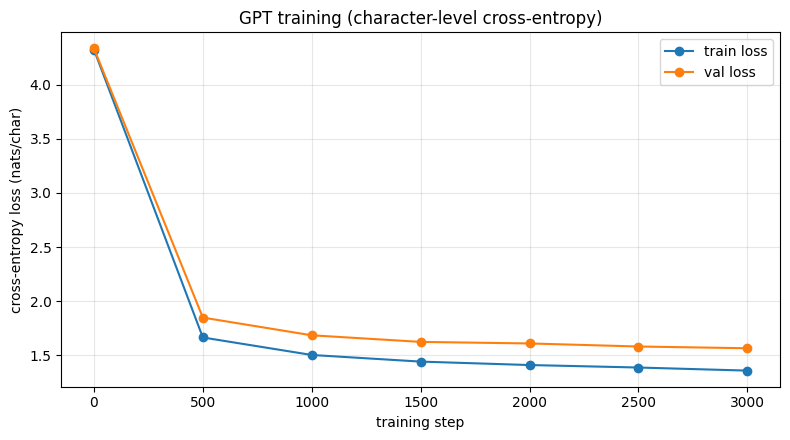

random-guess loss would be ln(vocab) = 4.174 nats; we reached 1.563


In [6]:
h = np.array(hist)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(h[:,0], h[:,1], "-o", label="train loss")
ax.plot(h[:,0], h[:,2], "-o", label="val loss")
ax.set_title("GPT training (character-level cross-entropy)")
ax.set_xlabel("training step"); ax.set_ylabel("cross-entropy loss (nats/char)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"random-guess loss would be ln(vocab) = {np.log(vocab):.3f} nats; we reached {h[-1,2]:.3f}")


**What to notice.** The loss drops well below the random-guess baseline $\ln(\text{vocab})$ — the model has learned real structure in the text (which characters follow which). A character-level loss around ~1.5 nats means the model is genuinely predictive. The train/val gap stays small here thanks to dropout + weight decay (NB6/NB9). Now the fun part — generate.


In [7]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)   # start from a single token
out = model.generate(context, max_new=500, temperature=0.8, top_k=40)[0].tolist()
print("".join(itos[i] for i in out))



His alry a sun sentence are the borne of such
one this his choose advancession mads
With him come it. Hastings, look'd upon the fool.

JULIET:
What lose thou son the people the greater of laws' sun
Thought: and when with a score that I may great them.

DUKE VINCENTIO:
Let's a maidter strike valiants to fliet this word.

KING HENRY VI

BUCK:
Then thy love blooking shion the quard's face.

KING HENRY VI:
Fares!

JULIET:
I was not bethink't, make the more than of the cast
Is threat the remedy. Yea,


**What to notice.** From a single starting token, the model generates text one character at a time (each new character fed back in) that has the *shape* of the training data — real words, capitalization, line breaks, punctuation, character-name-then-colon dialogue structure for Shakespeare. It's not memorizing (dropout + a val gap rule that out); it learned the statistics. This tiny model is a scaled-down GPT-2: **exactly the same architecture**, just fewer layers/dimensions and character (not BPE) tokens. Scale this up ~10,000× and you get GPT-3.


## 4. Look inside — attention maps of the trained model

Because we stashed the attention weights, we can visualize what a trained head attends to. We feed a short prompt and plot the causal attention pattern of a few heads in the first block.


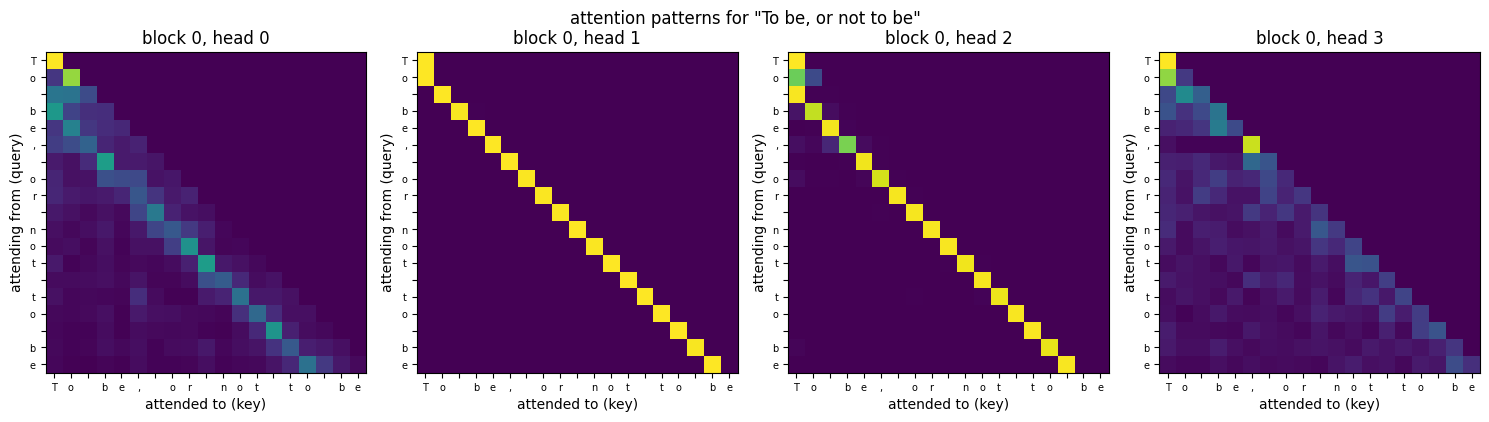

In [8]:
prompt = "To be, or not to be"
ids = torch.tensor([[stoi.get(c, 0) for c in prompt]], device=device)
model.eval()
with torch.no_grad(): model(ids)
att = model.blocks[0].attn.last_att[0]     # (n_heads, T, T)

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for hI in range(4):
    ax[hI].imshow(att[hI].cpu(), cmap="viridis")
    ax[hI].set_title(f"block 0, head {hI}")
    ax[hI].set_xticks(range(len(prompt))); ax[hI].set_xticklabels(list(prompt), fontsize=7)
    ax[hI].set_yticks(range(len(prompt))); ax[hI].set_yticklabels(list(prompt), fontsize=7)
    ax[hI].set_xlabel("attended to (key)"); ax[hI].set_ylabel("attending from (query)")
fig.suptitle('attention patterns for "To be, or not to be"'); plt.tight_layout(); plt.show()


**What to notice.** Each head learned a *different* attention pattern (all lower-triangular — the causal mask holds). Some heads attend strongly to the immediately-preceding character (local n-gram statistics), others reach further back or focus on specific characters like spaces/punctuation that mark word boundaries. This is the multi-head specialization from NB10, now emerged from training. Interpretability research on real LLMs does exactly this at scale — reading attention maps to reverse-engineer what the model computes.

## 5. What you built / learned
- A complete **decoder-only transformer**: token+positional embeddings → N × (causal-attention + MLP, each residual + pre-LN) → LM head.
- Verified the hand-written **causal multi-head attention** against PyTorch's fused kernel.
- **Trained** it on character-level text and **generated** coherent samples.
- Read the **attention maps** of the trained model.

This *is* GPT. Everything separating this from GPT-4 is scale (params, data, compute), better tokenization (NB12), and post-training (NB19–22) — not a different core idea.

## 6. Exercises
1. **Scale it.** Double `n_layers`, `d_model`, and steps. How much does val loss improve? (You're doing scaling laws by hand — NB18.)
2. **Ablate residuals.** Remove the residual connections (`x = attn(ln1(x))` instead of `x = x + …`). Watch training destabilize — the NB5 lesson, live.
3. **Ablate positional embedding.** Zero out `pos_emb`. How much worse is the model, and why (attention is order-blind)?
4. **Sampling knobs.** Generate at temperature {0.5, 1.0, 1.4} and top_k {5, 40, None}. Describe the coherence/diversity tradeoff (full treatment in NB13).
5. **Weight tying.** Tie `tok_emb.weight` to `head.weight` (a standard trick). Does it help at this scale?
6. **Count the FLOPs.** Estimate the forward-pass FLOPs of your model and where they go (attention vs MLP). At what sequence length does attention dominate? (Motivates NB16.)

## 7. Interview / residency framing
- *"Walk me through a GPT forward pass."* → embed tokens + positions → N blocks of [pre-LN → causal MHA → residual, pre-LN → MLP → residual] → final LN → LM head → next-token logits.
- *"Why pre-norm and residuals?"* → residuals = gradient highway for deep stacks (NB5); pre-LN keeps activations scaled and training stable.
- *"What makes it a *language model*?"* → causal mask + next-token cross-entropy; generation = autoregressive sampling feeding predictions back.
- *"Where do the parameters/compute go?"* → mostly the MLPs (4× width) and the attention projections; attention's *compute* scales $O(T^2)$ in sequence length.
- *"How is this different from GPT-3?"* → same architecture; GPT-3 is ~10^4× bigger with BPE tokens and vastly more data/compute.

---
**Next:** *Tier 2 · Notebook 12 — Tokenization / BPE from scratch*: build byte-pair encoding (the real tokenizer GPT uses), and understand why tokenization causes many of an LLM's weird failure modes.


## 📚 References & papers

This notebook reproduces / builds on:

- **Attention Is All You Need** — Vaswani et al. (2017), arXiv:1706.03762.
- **Improving Language Understanding by Generative Pre-Training (GPT)** — Radford et al. (2018).
- **Language Models are Unsupervised Multitask Learners (GPT-2)** — Radford et al. (2019).
- **Language Models are Few-Shot Learners (GPT-3)** — Brown et al. (2020), arXiv:2005.14165.
- **nanoGPT** — Karpathy (2022). The minimal GPT this notebook mirrors.